<a href="https://colab.research.google.com/github/amanvashisth/Deep-Learning/blob/master/Improve%20Neural%20Network%20Performance/Regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regularization in Deep Learning

**Regularization** is a technique used to **reduce overfitting** and improve the model's ability to **generalize to unseen data**.

Without regularization, a neural network may memorize the training data, resulting in:

- **Low training loss**
- **High validation/test loss**
- Poor generalization

Regularization adds constraints or modifications to the training process:

\[
\text{Total Loss} = \text{Training Loss} + \text{Regularization Penalty}
\]

## Why Do We Use Regularization?

- Reduce overfitting
- Improve generalization
- Prevent excessively complex models
- Make the model more robust to noise
- Improve validation/test performance

## Main Types of Regularization

### 1. L1 Regularization

Adds a penalty based on the absolute value of weights:

\[
L_{total}=L_{data}+\lambda\sum|w|
\]

**Properties:**
- Encourages sparse weights
- Can make some weights exactly zero
- Can perform implicit feature selection

```python
l1_penalty = sum(torch.sum(torch.abs(p)) for p in model.parameters())
loss = loss_fn(output, target) + l1_lambda * l1_penalty
```

---

### 2. L2 Regularization

Adds a penalty based on squared weights:

\[
L_{total}=L_{data}+\lambda\sum w^2
\]

**Properties:**
- Penalizes large weights
- Encourages smaller weights
- Usually does not make weights exactly zero
- Commonly implemented using `weight_decay`

```python
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)
```

**L1 vs L2:**

| L1 | L2 |
|---|---|
| Produces sparse weights | Produces smaller weights |
| Can make weights zero | Usually doesn't make weights zero |
| Feature selection | Controls weight magnitude |

---

### 3. Dropout

Randomly turns off a fraction of neurons during training.

```python
nn.Dropout(p=0.5)
```

**Properties:**
- Prevents the network from relying too heavily on specific neurons
- Reduces overfitting
- Active during training
- Disabled during evaluation/inference

---

### 4. Early Stopping

Stops training when validation performance stops improving.

```text
Training Loss ↓
Validation Loss ↓ → ↑
                    ↑
              Start overfitting
```

**Properties:**
- Prevents excessive training
- Stops the model before significant overfitting
- Saves the best-performing model

---

### 5. Data Augmentation

Creates modified versions of training data to increase its diversity.

Examples for images:

```python
RandomFlip()
RandomRotation()
RandomCrop()
```

**Properties:**
- Increases effective training data
- Reduces memorization
- Improves generalization

---

### 6. Batch Normalization

Normalizes activations during training.

```python
nn.BatchNorm1d(128)
```

It is primarily used for **stable and faster training**, but it can also provide a **regularizing effect**.

---

## Effect of Regularization on Training

### Too little regularization
Overfitting

Low training loss but poor validation/test performance.

### Appropriate regularization
Better Generalization

Slightly higher training loss can be acceptable if validation/test performance improves.

### Too much regularization
Underfitting


The model becomes too constrained and cannot learn the underlying patterns properly.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
import seaborn as sns
from mlxtend.plotting import plot_decision_regions

import tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.optimizers import Adam

In [2]:
X, y = make_moons(100, noise=0.25,random_state=2)

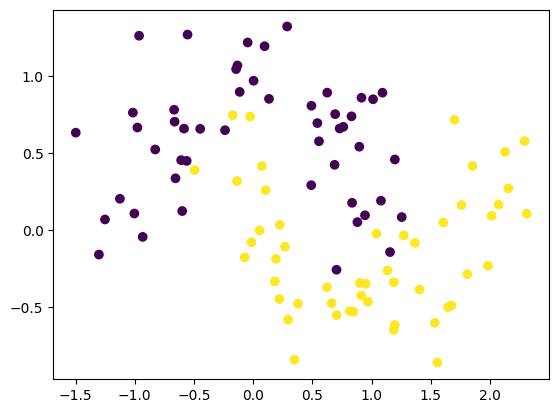

In [3]:
import matplotlib.pyplot as plt
plt.scatter(X[:,0], X[:,1], c=y)
plt.show()

In [4]:
model1 = Sequential() # Model Without Regularization

In [5]:
model1.add(Dense(128, input_dim=2, activation='relu'))
model1.add(Dense(128, activation='relu'))
model1.add(Dense(1, activation='sigmoid'))

model1.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
adam = Adam(learning_rate=0.01)

In [7]:
model1.compile(loss='binary_crossentropy', optimizer= adam, metrics=['accuracy'])
history1 = model1.fit(X, y, epochs=2000, validation_split = 0.2,verbose=0)

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step


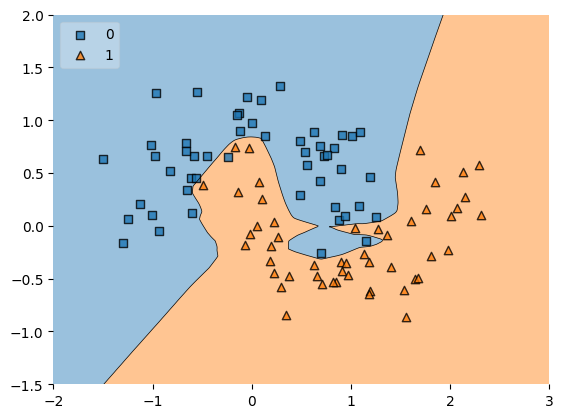

In [8]:
plot_decision_regions(X, y.astype('int'), clf=model1, legend=2)
plt.xlim(-2,3)
plt.ylim(-1.5,2)
plt.show()

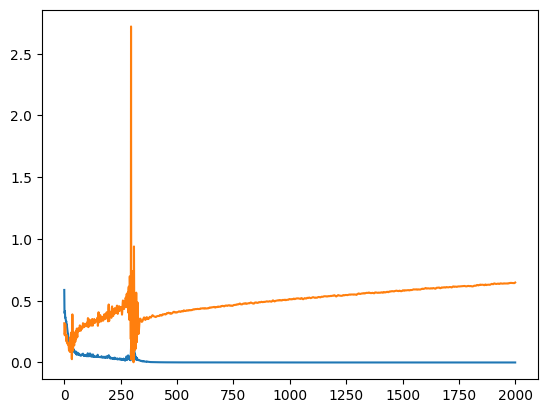

In [9]:
plt.plot(history1.history['loss'])
plt.plot(history1.history['val_loss'])

In [29]:
model2 = Sequential()

L2_Regulaizer = tensorflow.keras.regularizers.l2(0.001)
L1_Regulaizer = tensorflow.keras.regularizers.l1(0.001)

In [30]:
model2.add(Dense(128, input_dim=2, activation='relu', kernel_regularizer=L1_Regulaizer))
model2.add(Dense(128, activation='relu', kernel_regularizer=L1_Regulaizer))
model2.add(Dense(1, activation='sigmoid'))

model2.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_27 (Dense)                │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
adam = Adam(learning_rate=0.01)
model2.compile(loss='binary_crossentropy', optimizer=adam, metrics=['accuracy'])

history2 = model2.fit(X, y, epochs=2000, validation_split = 0.2,verbose=0)

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 13s 1ms/step


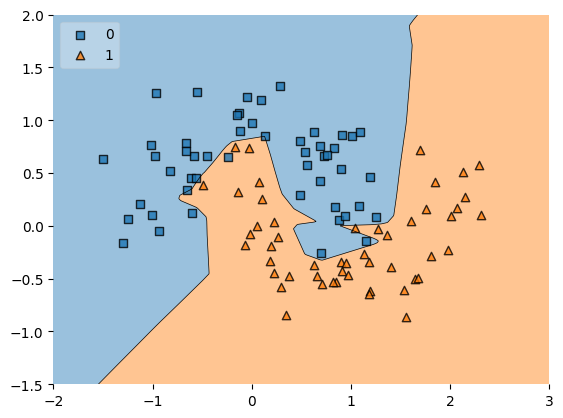

In [24]:
plot_decision_regions(X, y.astype('int'), clf=model2, legend=2)
plt.xlim(-2,3)
plt.ylim(-1.5,2)
plt.show()

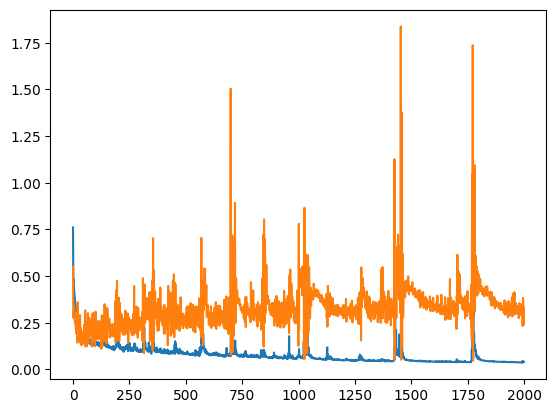

In [25]:
plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])

In [26]:
model1_weight_layer1 = model1.get_weights()[0].reshape(256)
model2_weight_layer1 = model2.get_weights()[0].reshape(256)

<Axes: >

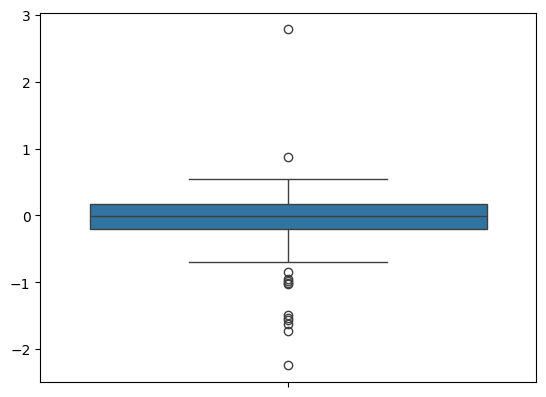

In [27]:
sns.boxplot(model1_weight_layer1)

<Axes: >

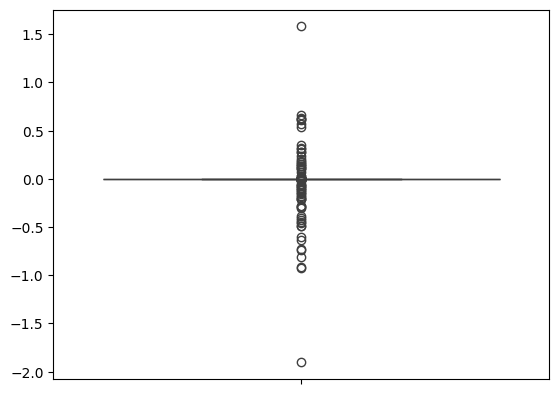

In [28]:
sns.boxplot(model2_weight_layer1)